# Autoencoder Anomaly Detection

This notebook uses an **Autoencoder** neural network to detect anomalies in spectra data, following the same workflow as the other model notebooks.

**Core idea:**
- An autoencoder is trained to compress a spectrum down to a small **latent representation** and then reconstruct it back to the original
- Trained exclusively on `all_spectra.csv` (normal samples), the network learns to efficiently reconstruct normal spectra
- When given an **ambient (anomalous)** spectrum, the network has never learned its pattern, so it **reconstructs it poorly**
- The **anomaly score** is the **mean squared reconstruction error** — high error means the sample looks nothing like what the model learned

**Architecture:**
```
Input (535) → Encoder → Latent (LATENT_DIM) → Decoder → Reconstruction (535)
```
The encoder and decoder are symmetric: the decoder mirrors the encoder layers in reverse.

**Advantage over KNN / Isolation Forest:** The autoencoder learns a non-linear manifold of normal spectra. It can capture complex spectral patterns that distance-based or tree-based methods miss.

**Goal:** Evaluate whether the model can correctly identify `ambient_spectra.csv` particles as anomalies.

## 1. Hyperparameters

All settings are defined here so you can experiment without hunting through the code.

| Parameter | Description |
|-----------|-------------|
| `HIDDEN_DIMS` | List of hidden layer sizes for the encoder. The decoder mirrors these in reverse. E.g. `[512, 256, 128]` creates a 3-layer encoder going 535 → 512 → 256 → 128 → latent |
| `LATENT_DIM` | Size of the bottleneck layer. Smaller = more compressed representation, harder to reconstruct; larger = less compression, easier to reconstruct |
| `LEARNING_RATE` | Step size for the Adam optimizer. Too high = unstable loss; too low = slow convergence |
| `EPOCHS` | Number of full passes through the training data |
| `BATCH_SIZE` | Number of samples per gradient update. Larger = more stable gradients |
| `THRESHOLD_PERCENTILE` | Percentile of normal training reconstruction errors used as the decision threshold. Scores above this are flagged as anomalies |

In [2]:
# ── Tune these values to experiment with the model ──────────────────────────

HIDDEN_DIMS          = [512, 256, 128]  # encoder hidden layer sizes (decoder mirrors in reverse)
LATENT_DIM           = 64              # bottleneck dimension
LEARNING_RATE        = 1e-3            # Adam optimizer learning rate
EPOCHS               = 100             # number of training epochs
BATCH_SIZE           = 64             # samples per gradient update
THRESHOLD_PERCENTILE = 95             # percentile of normal training scores used as decision threshold

# ─────────────────────────────────────────────────────────────────────────────

## 2. Imports

Loading all libraries needed for data handling, the autoencoder model, training, and evaluation.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (                           # evaluation tools
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## 3. Load Data

- `all_spectra.csv` → **normal** particles. The model trains exclusively on these.
- `ambient_spectra.csv` → **anomaly** particles. Only used at evaluation time — the model never sees them during training.

Only the wavelength intensity columns are used as features. The `polymer` label column is dropped.

In [4]:
# Load both datasets; the unnamed first column is the row index
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Identify the label column and keep only wavelength columns as features
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices — rows = samples, columns = wavelength intensities
X_normal  = all_spectra[wavelengths].values.astype(np.float32)   # shape: (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values.astype(np.float32)  # shape: (55, 535)

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')
print(f'Features (wavelengths): {X_normal.shape[1]}')

Normal samples  : (1215, 535)
Anomaly samples : (55, 535)
Features (wavelengths): 535


## 4. Define Autoencoder Architecture

The autoencoder has two symmetric parts:

- **Encoder** — progressively compresses the input spectrum through `HIDDEN_DIMS` layers down to `LATENT_DIM`
- **Decoder** — mirrors the encoder in reverse, expanding from `LATENT_DIM` back to the original 535-dimensional spectrum

**Activation functions:** ReLU between all hidden layers. The decoder output has no activation (linear) so reconstructions are unconstrained real values, matching the input spectrum range.

With default settings the full architecture is:
```
Encoder: 535 → 512 → 256 → 128 → 64
Decoder:  64 → 128 → 256 → 512 → 535
```

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, latent_dim):
        super().__init__()

        # Build encoder: input_dim → hidden_dims → latent_dim
        encoder_layers = []
        in_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(in_dim, h))
            encoder_layers.append(nn.ReLU())
            in_dim = h
        encoder_layers.append(nn.Linear(in_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # Build decoder: latent_dim → hidden_dims reversed → input_dim
        decoder_layers = []
        in_dim = latent_dim
        for h in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(in_dim, h))
            decoder_layers.append(nn.ReLU())
            in_dim = h
        decoder_layers.append(nn.Linear(in_dim, input_dim))  # linear output — no activation
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


# Instantiate model and move to device
input_dim = X_normal.shape[1]
model     = Autoencoder(input_dim, HIDDEN_DIMS, LATENT_DIM).to(device)

# Print architecture summary
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTotal trainable parameters: {total_params:,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=535, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=535, bias=True)
  )
)

Total trainable parameters: 894,295


## 5. Train Autoencoder

The model is trained exclusively on **normal samples** — no labels are used. The objective is to minimize the **mean squared error (MSE)** between each input spectrum and its reconstruction.

After training, the model will have learned to efficiently reconstruct spectra that look like the normal training data. It will struggle to reconstruct spectra it has never encountered (ambient anomalies), resulting in high reconstruction error for those samples.

The training loss curve is plotted after training to verify convergence.

In [ ]:
# Wrap training data in a DataLoader for mini-batch gradient descent
X_tensor = torch.tensor(X_normal, dtype=torch.float32)
dataset  = TensorDataset(X_tensor)
loader   = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss() # loss function is MSE loss (true label - predicted) ^ 2

# Training loop
train_losses = []
model.train()

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstructed = model(batch)
        loss          = criterion(reconstructed, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)

    epoch_loss /= len(X_normal)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1:3d}/{EPOCHS}]  Loss: {epoch_loss:.6f}')

print('\nTraining complete.')

Epoch [ 10/100]  Loss: 0.178785
Epoch [ 20/100]  Loss: 0.121192
Epoch [ 30/100]  Loss: 0.104933
Epoch [ 40/100]  Loss: 0.086315
Epoch [ 50/100]  Loss: 0.069646
Epoch [ 60/100]  Loss: 0.055464
Epoch [ 70/100]  Loss: 0.044326
Epoch [ 80/100]  Loss: 0.035356
Epoch [ 90/100]  Loss: 0.029526
Epoch [100/100]  Loss: 0.024452

Training complete.


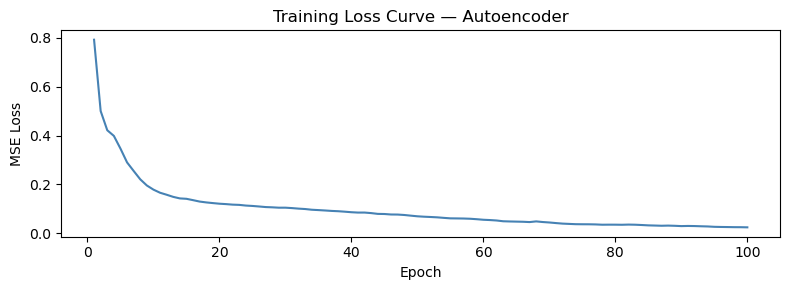

Final training loss: 0.024452


In [7]:
# Plot the training loss curve to verify the model converged
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, EPOCHS + 1), train_losses, color='steelblue', lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss Curve — Autoencoder')
plt.tight_layout()
plt.show()

print(f'Final training loss: {train_losses[-1]:.6f}')

## 6. Compute Anomaly Scores

For each sample, the **anomaly score** is the **mean squared error** between the original spectrum and its reconstruction:

$$\text{score}(x) = \frac{1}{D} \sum_{i=1}^{D} (x_i - \hat{x}_i)^2$$

- **Low score** → the model reconstructed the spectrum accurately → the spectrum looks like what the model learned → likely **normal**
- **High score** → the model failed to reconstruct the spectrum → the spectrum is unfamiliar to the model → likely **anomalous**

Scores are computed for both the normal samples (to set the threshold) and the ambient samples (to evaluate).

In [8]:
model.eval()
with torch.no_grad():
    X_normal_tensor  = torch.tensor(X_normal,  dtype=torch.float32).to(device)
    X_anomaly_tensor = torch.tensor(X_anomaly, dtype=torch.float32).to(device)

    recon_normal  = model(X_normal_tensor).cpu().numpy()
    recon_anomaly = model(X_anomaly_tensor).cpu().numpy()

# Anomaly score = mean squared reconstruction error per sample
scores_normal  = np.mean((X_normal  - recon_normal)  ** 2, axis=1)  # shape: (1215,)
scores_anomaly = np.mean((X_anomaly - recon_anomaly) ** 2, axis=1)  # shape: (55,)

print(f'Normal  scores — min: {scores_normal.min():.4f}  max: {scores_normal.max():.4f}  mean: {scores_normal.mean():.4f}')
print(f'Anomaly scores — min: {scores_anomaly.min():.4f}  max: {scores_anomaly.max():.4f}  mean: {scores_anomaly.mean():.4f}')

Normal  scores — min: 0.0022  max: 0.2139  mean: 0.0240
Anomaly scores — min: 0.0298  max: 0.9166  mean: 0.2858


## 7. Set Decision Threshold

The threshold is the reconstruction error above which a sample is declared an anomaly. It is set using a percentile of the **normal training scores** — meaning the model decides what "unusually high reconstruction error" looks like based on the normal data itself.

- `THRESHOLD_PERCENTILE = 95` → the top 5% hardest-to-reconstruct normal samples set the bar. Anything above this is flagged as an anomaly.
- **Raising** the percentile makes the model more lenient (fewer anomaly detections).
- **Lowering** the percentile makes the model more aggressive (more anomaly detections, but more false positives).

In [9]:
# Set threshold as the chosen percentile of normal sample reconstruction errors
threshold = np.percentile(scores_normal, THRESHOLD_PERCENTILE)

print(f'Threshold (p{THRESHOLD_PERCENTILE} of normal scores): {threshold:.6f}')
print(f'Any sample with a reconstruction error above {threshold:.6f} will be flagged as an anomaly')

Threshold (p95 of normal scores): 0.077469
Any sample with a reconstruction error above 0.077469 will be flagged as an anomaly


## 8. Anomaly Score Distribution

Histogram of reconstruction errors for normal (blue) and ambient (orange) samples. The red dashed line marks the decision threshold.

**What to look for:**
- If the two distributions are well separated, the autoencoder is clearly distinguishing normal from anomalous samples
- If they overlap heavily, the model is reconstructing ambient spectra just as well as normal ones — try increasing `EPOCHS`, reducing `LATENT_DIM`, or adjusting `HIDDEN_DIMS`

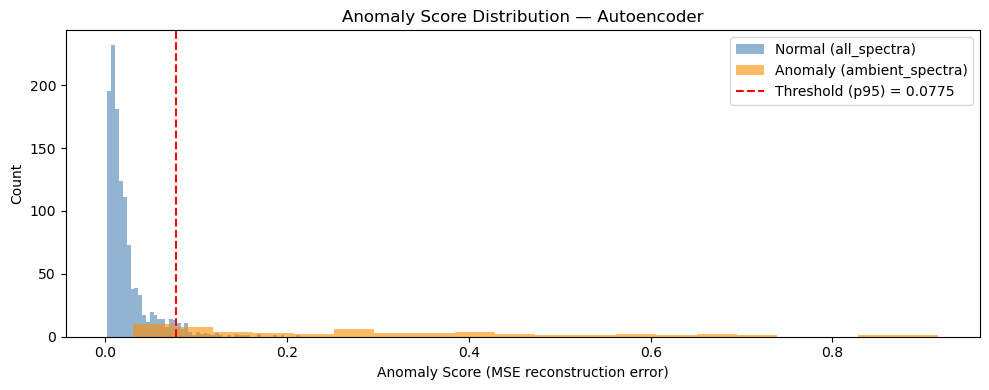

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot score distributions for both classes
ax.hist(scores_normal,  bins=50, alpha=0.6, color='steelblue',  label='Normal (all_spectra)')
ax.hist(scores_anomaly, bins=20, alpha=0.6, color='darkorange', label='Anomaly (ambient_spectra)')

# Draw the decision threshold
ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold (p{THRESHOLD_PERCENTILE}) = {threshold:.4f}')

ax.set_xlabel('Anomaly Score (MSE reconstruction error)')
ax.set_ylabel('Count')
ax.set_title('Anomaly Score Distribution — Autoencoder')
ax.legend()
plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the plot here)*

## 9. Evaluate Performance

Predictions are made by comparing each sample's reconstruction error against the threshold. Standard classification metrics are then used to measure performance.

- **Label convention:** `0` = normal, `1` = anomaly
- **Precision** — of all samples flagged as anomalies, how many actually were?
- **Recall** — of all actual anomalies, how many did the model catch?
- **F1** — harmonic mean of precision and recall
- **ROC-AUC** — overall ability to rank anomalies above normal samples (1.0 = perfect, 0.5 = random)

In [11]:
# Combine scores and true labels for evaluation
# 0 = normal, 1 = anomaly
all_scores  = np.concatenate([scores_normal, scores_anomaly])
true_labels = np.concatenate([
    np.zeros(len(scores_normal)),   # normal samples labeled 0
    np.ones(len(scores_anomaly))    # anomaly samples labeled 1
])

# Predict: reconstruction error above threshold → anomaly (1), otherwise normal (0)
pred_labels = (all_scores > threshold).astype(int)

# Compute ROC-AUC using raw scores (threshold-independent)
roc_auc = roc_auc_score(true_labels, all_scores)

print(f'ROC-AUC Score : {roc_auc:.4f}\n')
print('Classification Report:')
print(classification_report(true_labels, pred_labels, target_names=['Normal', 'Anomaly']))

ROC-AUC Score : 0.9719

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97      1215
     Anomaly       0.42      0.82      0.56        55

    accuracy                           0.94      1270
   macro avg       0.71      0.88      0.76      1270
weighted avg       0.97      0.94      0.95      1270



**Results:** *(run the cell and interpret the output here)*

## 10. Confusion Matrix

The confusion matrix breaks down predictions into correct and incorrect categories:

|  | Predicted Normal | Predicted Anomaly |
|--|--|--|
| **Actually Normal** | True Negative (TN) | False Positive (FP) |
| **Actually Anomaly** | False Negative (FN) | True Positive (TP) |

For anomaly detection, **False Negatives (FN)** are the most costly — these are real anomalies the model missed.

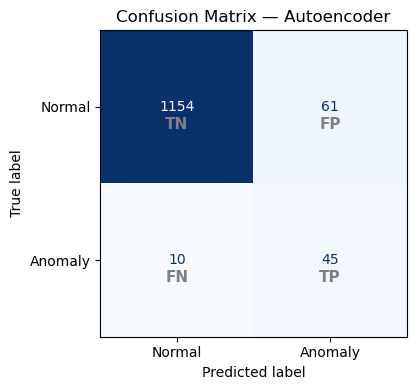

In [12]:
# Compute and display the confusion matrix
cm   = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Autoencoder')

# Label each cell with TP, TN, FP, FN
labels = [['TN', 'FP'],
          ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'\n\n{labels[i][j]}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='gray')

plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the confusion matrix here)*

## 11. ROC Curve

The ROC curve plots the **True Positive Rate** (anomalies correctly caught) against the **False Positive Rate** (normal samples incorrectly flagged) across all possible thresholds.

- A curve hugging the top-left corner = excellent model
- A diagonal line = random guessing (AUC = 0.5)

This is useful because it shows performance independent of the threshold you chose.

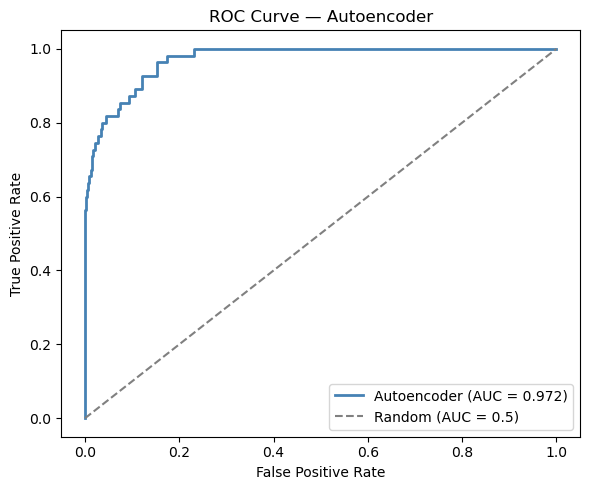

In [13]:
# Compute the ROC curve across all thresholds
fpr, tpr, _ = roc_curve(true_labels, all_scores)

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the Autoencoder ROC curve
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Autoencoder (AUC = {roc_auc:.3f})')

# Plot the random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Autoencoder')
ax.legend()
plt.tight_layout()
plt.show()

**Results:** *(run the cell and interpret the ROC curve here)*